In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Users/USER/Desktop/project/Fraud Detection Dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
# Checking null values in the dataset.
print(df.isna().sum())
plt.show()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [5]:
# Checking columns and their data types
df.dtypes

Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

In [6]:
# Handle null values
for c in df.columns:
  if df[c].dtype == "object":
    df[c] = df[c].fillna("Unknown")
  else:
    df[c] = df[c].fillna(df[c].median())

df.isna().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [7]:
# Transaction amount done using the various types of payment methods.

ax = df["Transaction_Amount"].groupby(df["Payment_Method"]).describe()
ax

,count,mean,std,min,25%,50%,75%,max
Payment_Method,,,,,,,,
Credit Card,11646.0,3003.008095,5091.922636,5.47,1326.0125,2524.1,3735.9800,49997.8
Debit Card,11802.0,2981.789207,5041.615095,5.04,1306.7900,2524.1,3684.3375,49997.8
Invalid Method,1530.0,2968.756124,5178.086930,5.49,1243.2525,2524.1,3672.6575,49997.8
Net Banking,11666.0,2929.259117,4635.018674,5.55,1362.4500,2524.1,3736.4425,49997.8
UPI,11887.0,2953.908955,4755.332531,5.03,1350.6500,2524.1,3740.1100,49997.8
Unknown,2469.0,3089.009145,5384.882214,8.11,1397.5200,2524.1,3742.7700,49997.8


In [8]:
# Transaction amount done using the various devices.

bx = df["Transaction_Amount"].groupby(df["Device_Used"]).describe()
bx

,count,mean,std,min,25%,50%,75%,max
Device_Used,,,,,,,,
Desktop,15795.0,2971.527100,4886.564710,5.04,1335.040,2524.1,3747.7150,49997.8
Mobile,15614.0,2999.391882,5066.626072,5.49,1341.575,2524.1,3709.9150,49997.8
Tablet,15588.0,2953.664185,4857.769852,5.03,1316.060,2524.1,3708.1075,49997.8
Unknown,2473.0,2935.329996,4674.664280,11.53,1360.650,2524.1,3746.4500,49997.8
Unknown Device,1530.0,2974.090046,4722.949007,5.63,1429.085,2524.1,3690.3325,49997.8


In [9]:
# Transaction amount done in the various locations

cx = df["Transaction_Amount"].groupby(df["Location"]).describe()
cx

,count,mean,std,min,25%,50%,75%,max
Location,,,,,,,,
Boston,6149.0,2959.049382,4719.136687,5.55,1383.3900,2524.1,3742.7000,49997.8
Chicago,6071.0,2944.604599,4750.505472,8.14,1348.9250,2524.1,3729.5250,49997.8
Houston,6031.0,2955.039385,4956.333210,5.03,1305.1450,2524.1,3690.8300,49997.8
Los Angeles,6012.0,3022.511382,5180.247985,5.97,1298.2150,2524.1,3739.6850,49997.8
Miami,5991.0,2985.808820,5008.871434,5.49,1305.8050,2524.1,3735.8350,49997.8
New York,6110.0,2991.466943,5068.958809,5.52,1322.1175,2524.1,3687.6425,49997.8
San Francisco,5985.0,2905.124608,4622.929969,5.63,1333.4000,2524.1,3691.5600,49997.8
Seattle,6104.0,3051.718010,5208.453063,5.04,1369.4825,2524.1,3749.4650,49997.8
Unknown,2547.0,2894.837161,4420.982341,5.08,1350.2500,2524.1,3756.8850,49997.8


In [10]:
# Transaction amount in the whole dataset
df["Transaction_Amount"].describe()

count    51000.000000
mean      2972.920030
std       4918.801144
min          5.030000
25%       1333.787500
50%       2524.100000
75%       3724.987500
max      49997.800000
Name: Transaction_Amount, dtype: float64

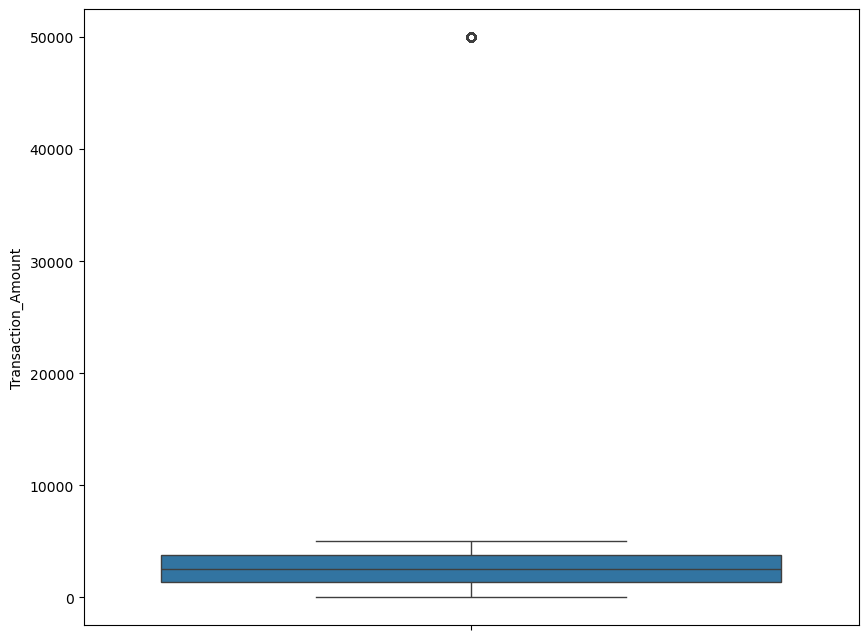

In [11]:
# Boxplot of the transaction amount done.
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, y="Transaction_Amount")
plt.show()

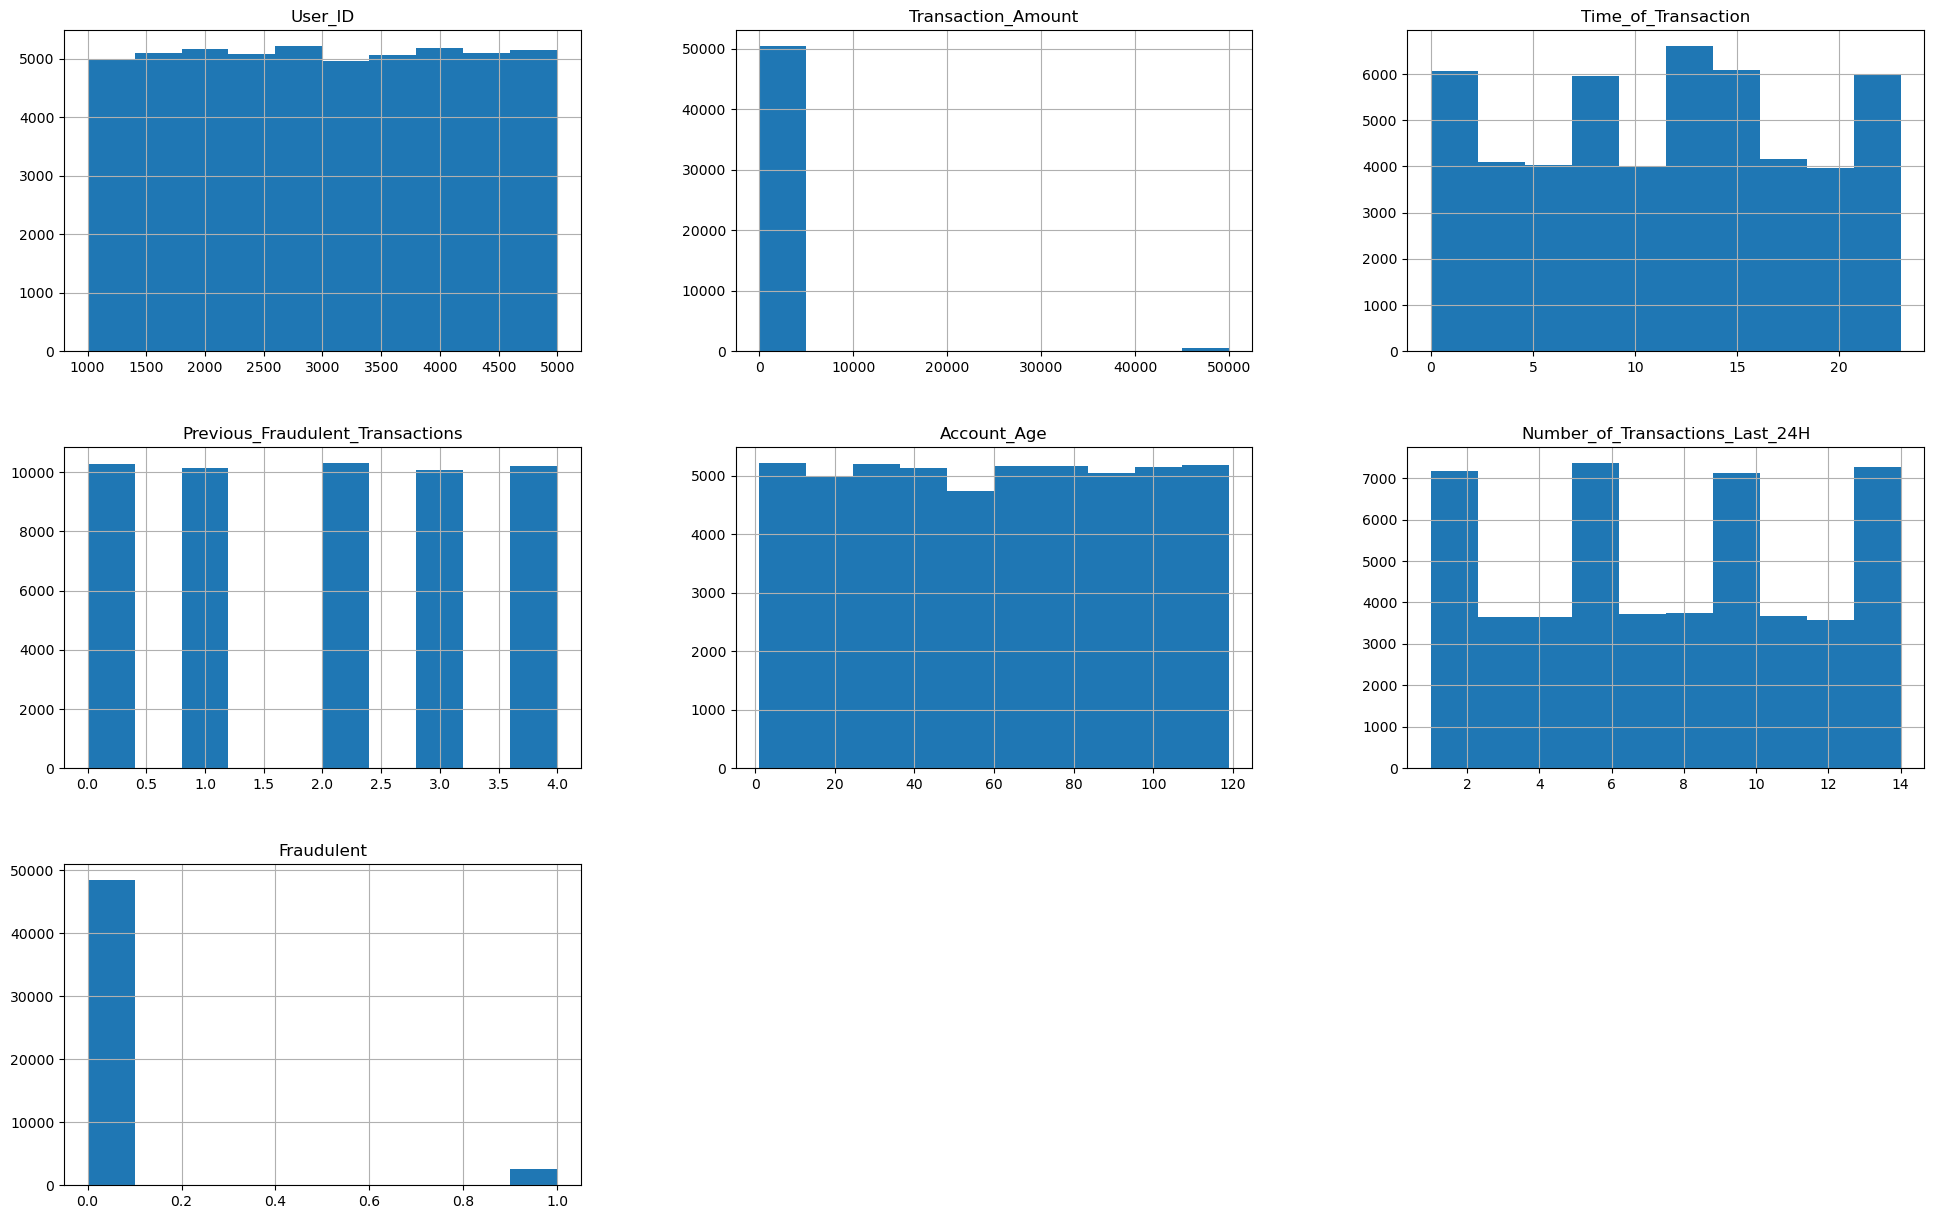

In [12]:
# Histogram for the data

df.hist(figsize=(24, 15))
plt.show()

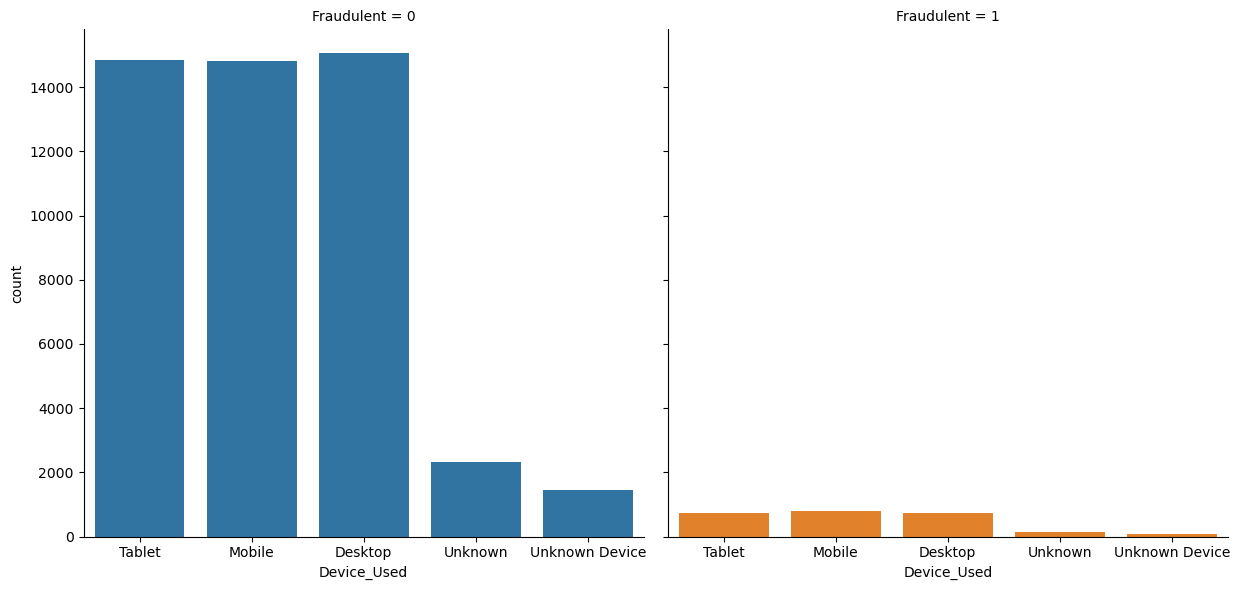

In [13]:
# Devices Used with the Fraudulent transactions

def cp(x, color, **kwargs):
  sns.countplot(x=x, color=color, **kwargs)

fg = sns.FacetGrid(data=df, col="Fraudulent", hue="Fraudulent", col_wrap=5, height=6)
fg.map(cp, "Device_Used")
plt.show()

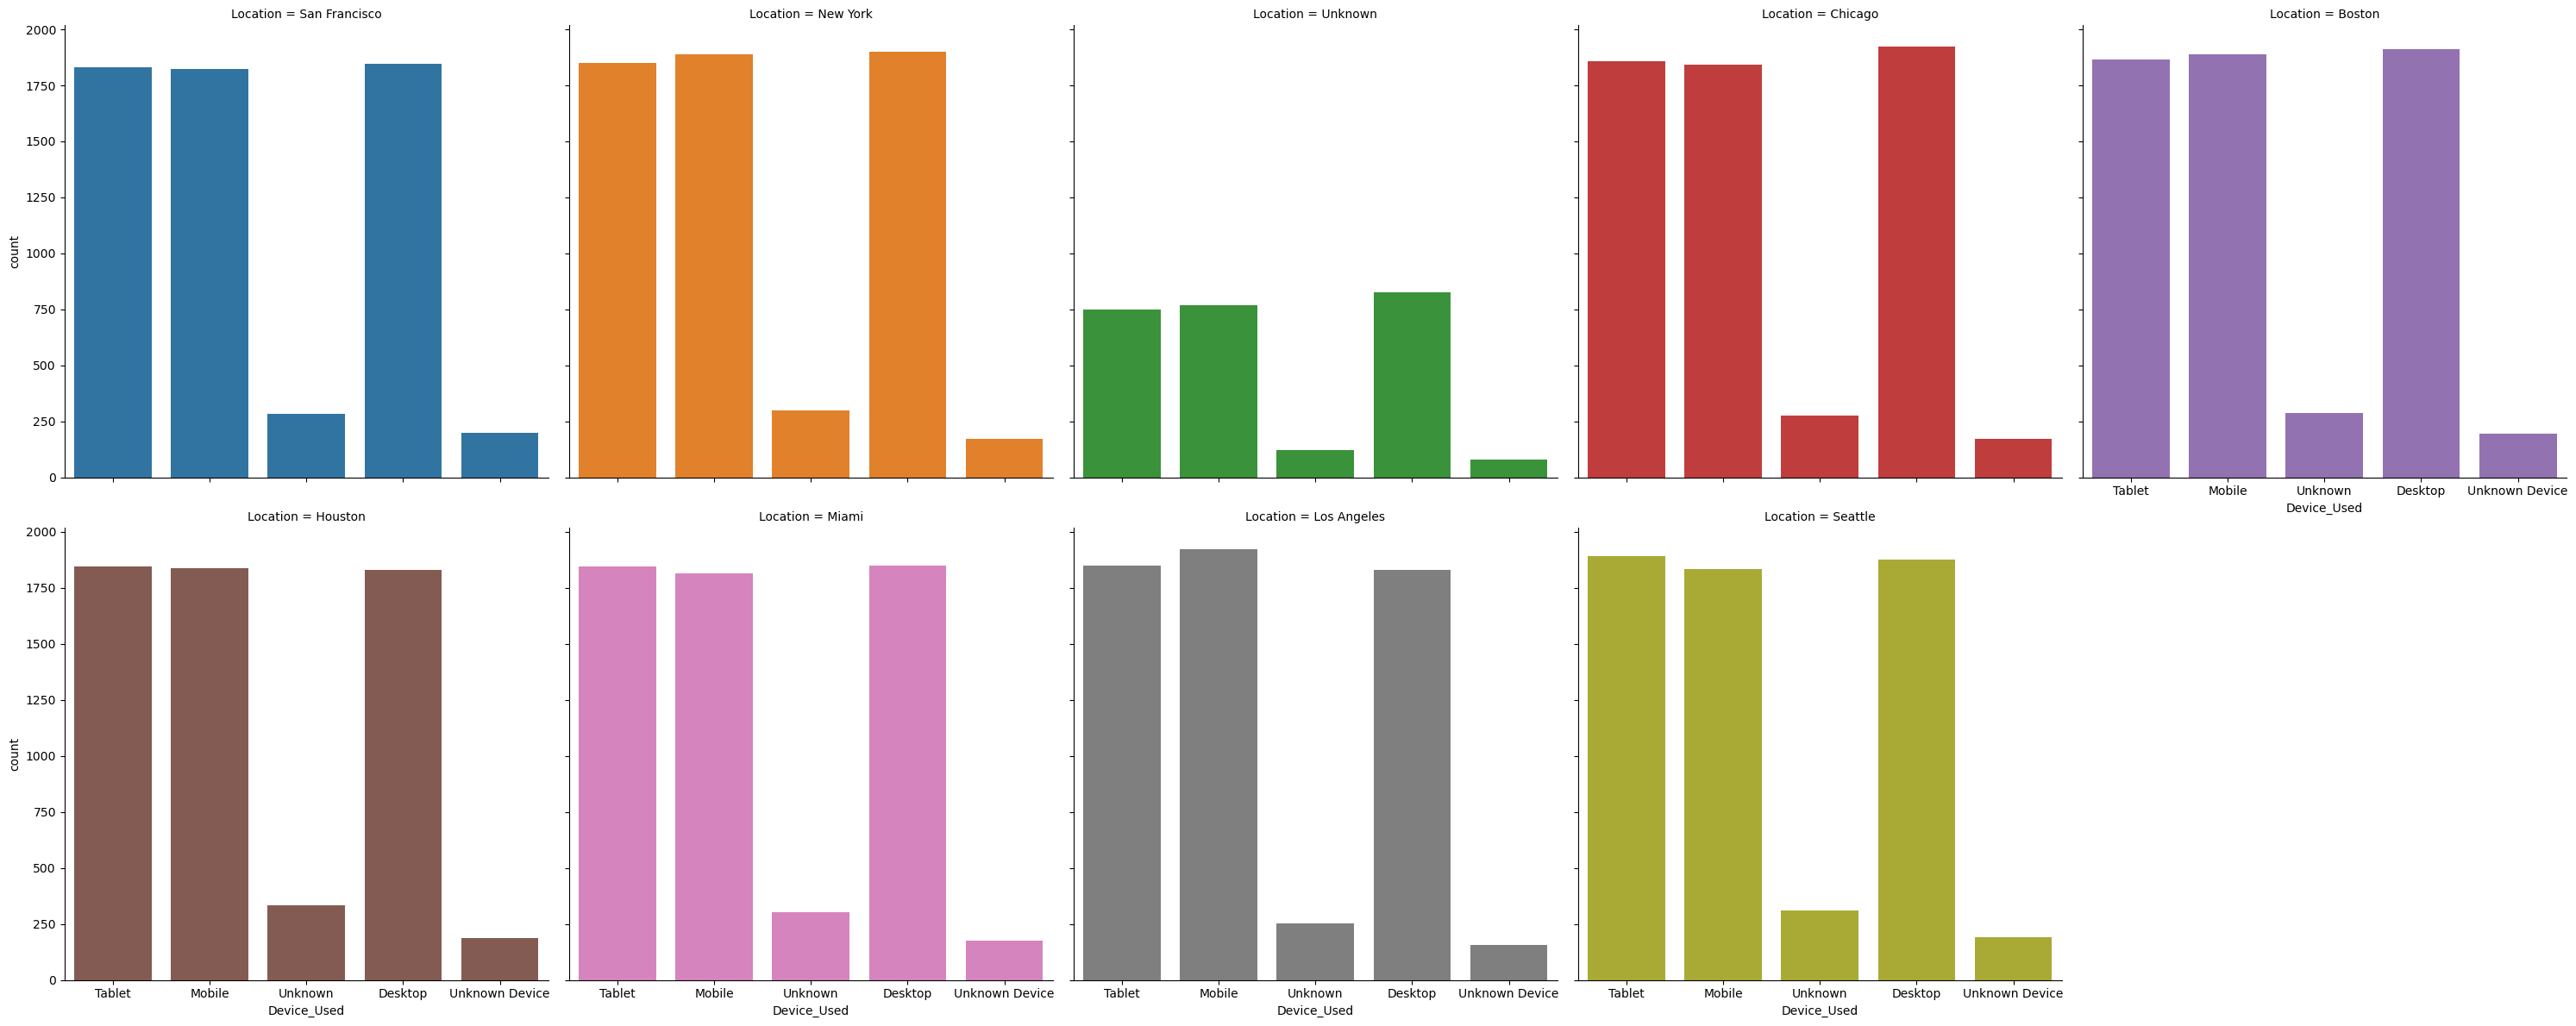

In [14]:
# Device Used in relation to the Location of the transaction

fg = sns.FacetGrid(data=df, col="Location", hue="Location", col_wrap=5, height=6)
fg.map(cp, "Device_Used")
plt.show()

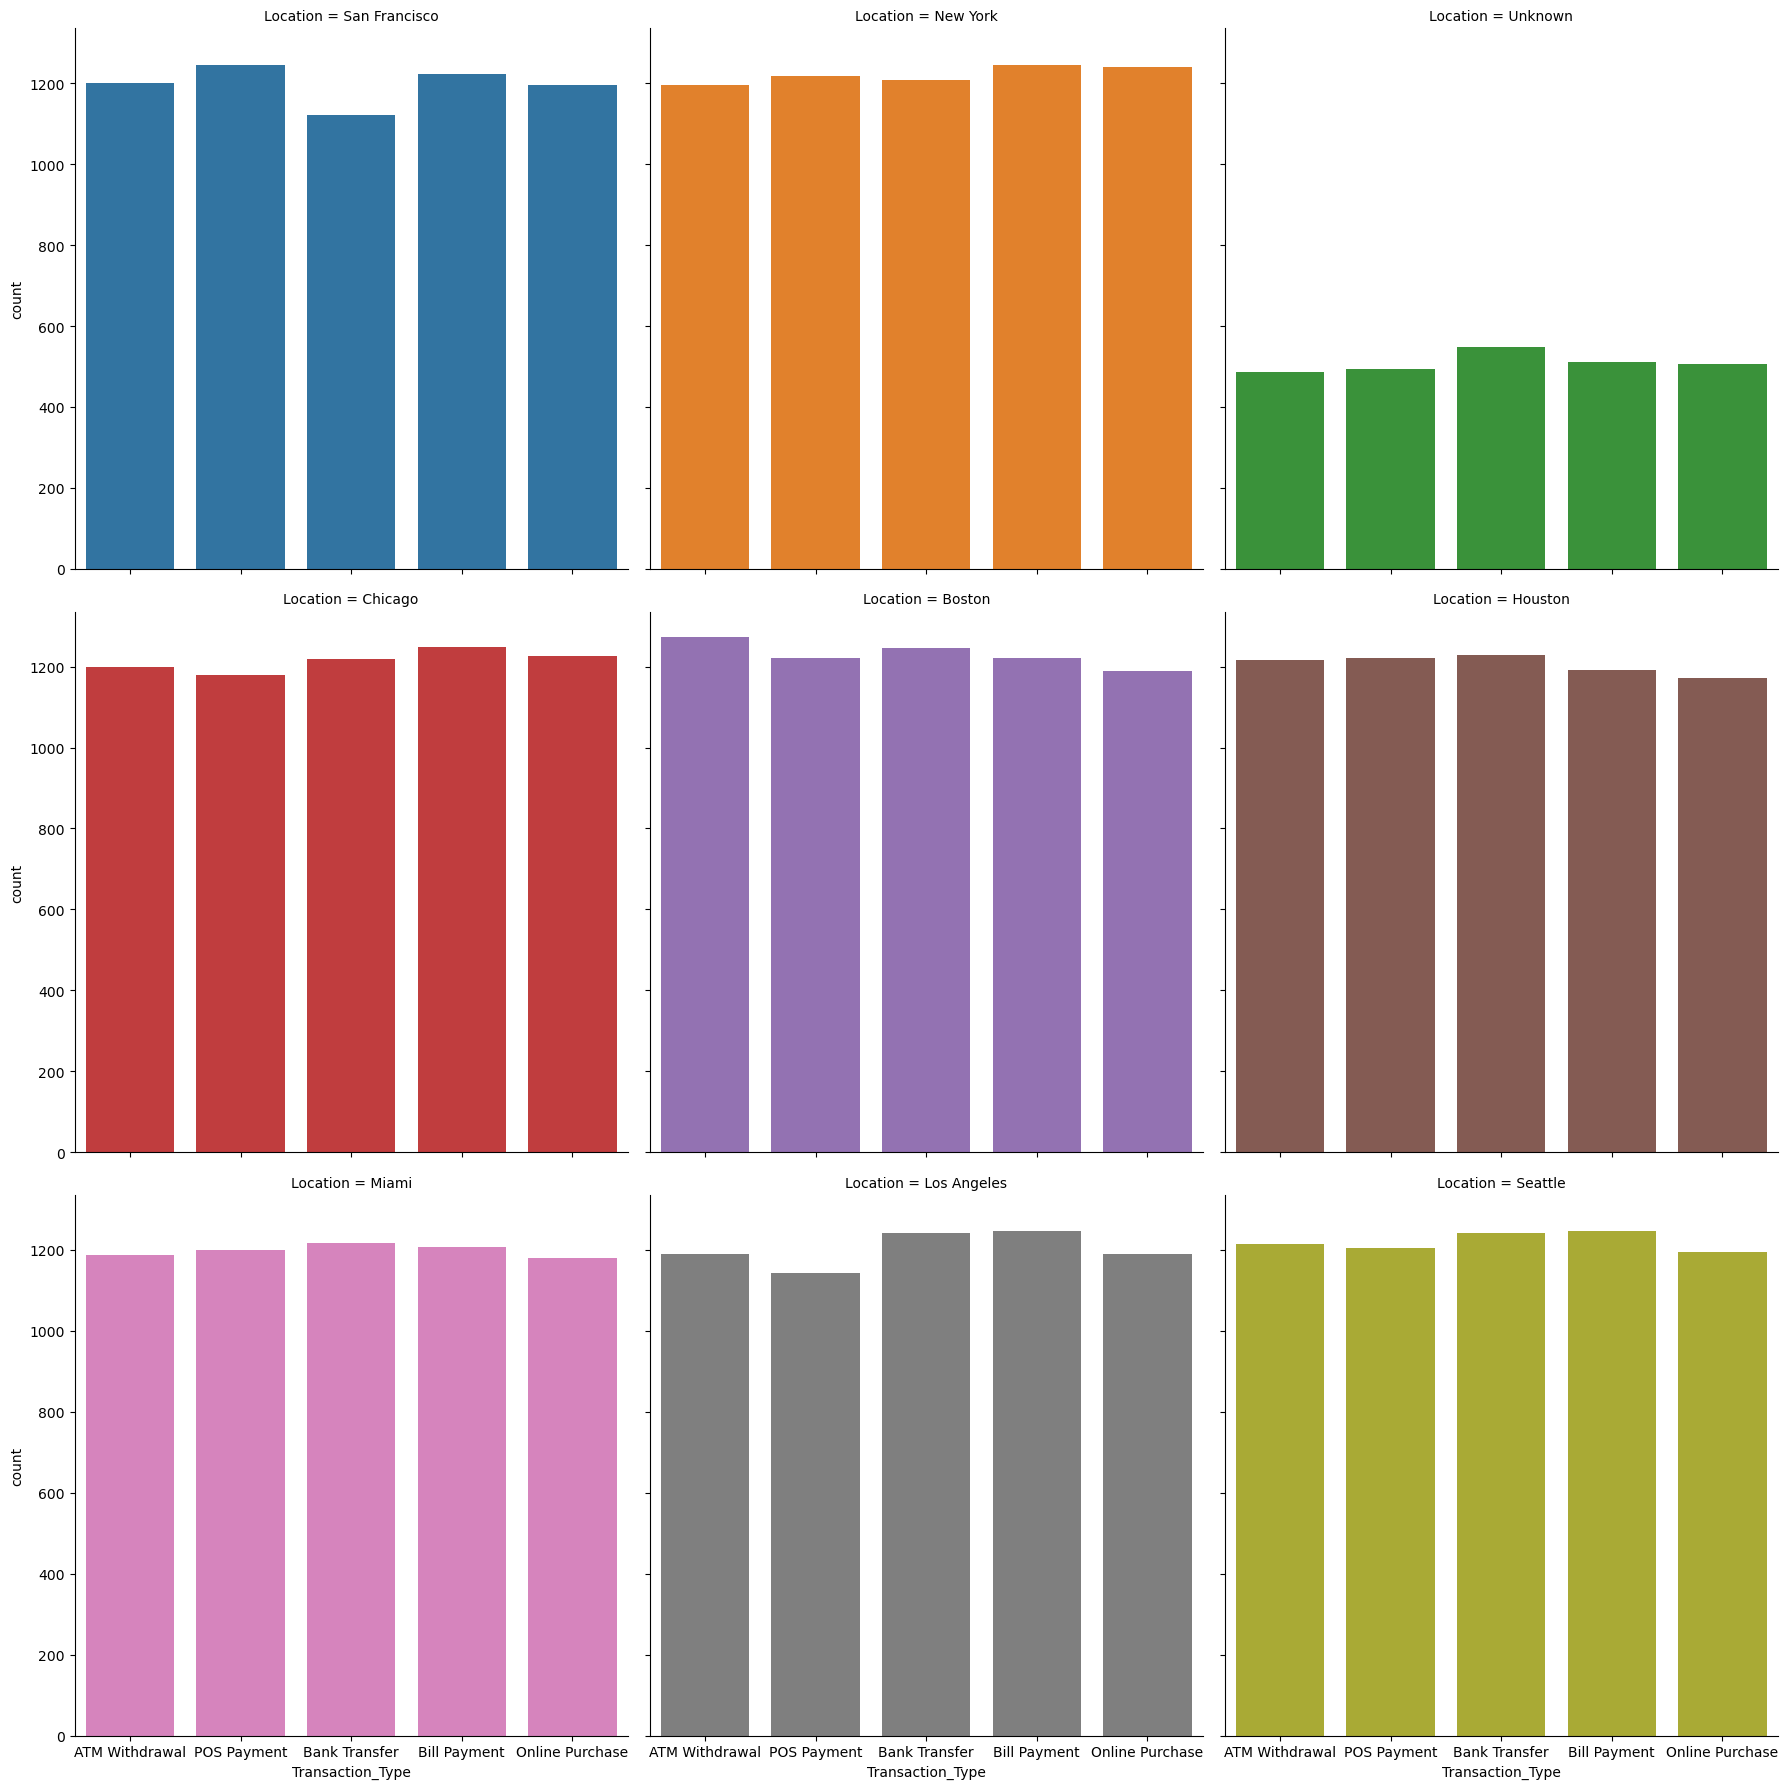

In [16]:
# Transaction Type in relation to the Location of the transaction

fg = sns.FacetGrid(data=df, col="Location", hue="Location", col_wrap=3, height=6)
fg.map(cp, "Transaction_Type")
plt.show()

In [17]:
#Data processing
from sklearn.preprocessing import LabelEncoder as le

cf = df.copy()

# Transform columns with object values.
for c in df.columns:
  if cf[c].dtypes != "float64" and cf[c].dtypes != "int64":
    cf[c] = le().fit_transform(cf[c])
  
cf

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,0,4174,1292.76,0,16.0,2,6,0,119,13,1,0
1,11111,4507,1554.58,0,13.0,1,5,4,79,3,0,0
2,22222,1860,2395.02,0,12.0,1,8,3,115,9,5,0
3,33333,2294,100.10,2,15.0,0,1,4,3,4,4,0
4,44444,2130,1490.50,4,19.0,1,6,2,57,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,26648,2339,3112.51,2,15.0,1,5,0,7,8,1,0
50996,23626,2152,2897.15,3,3.0,1,4,1,75,11,3,1
50997,2550,3345,2204.43,4,18.0,1,6,3,73,5,0,0
50998,35876,1518,4787.17,4,19.0,2,5,2,108,14,3,0


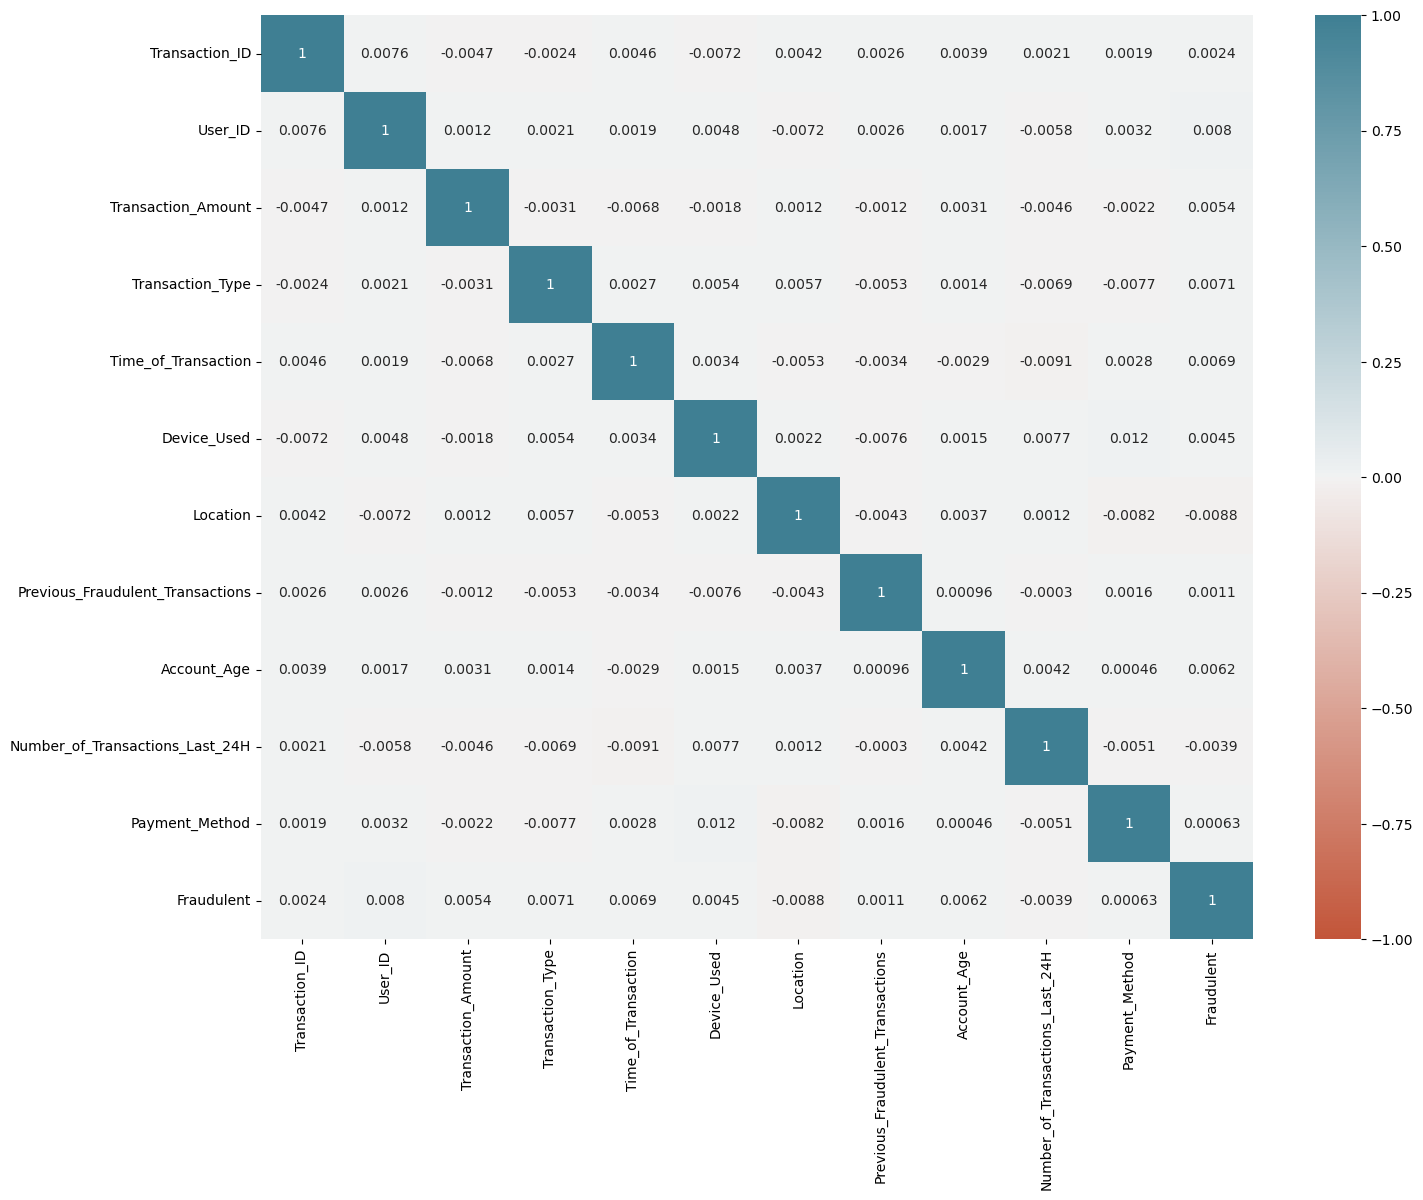

In [18]:
# Coorelation of the columns

plt.figure(figsize=(16, 12))
sns.heatmap(data=cf.corr(), annot=True,vmax=1, vmin=-1, cmap=sns.diverging_palette(20, 220, as_cmap=True))
plt.show()

TypeError: IsolationForest.__init__() got an unexpected keyword argument 'max_depth'